# STUDI KASUS: Klasifikasi Jenis Cuaca
# Algoritma: Random Forest

# FASE 1 - Business Understanding

## 1. Latar Belakang
Cuaca merupakan faktor lingkungan yang berdampak langsung pada berbagai sektor kehidupan seperti
pertanian, transportasi, pariwisata, dan keselamatan publik. Penentuan jenis cuaca secara manual
membutuhkan waktu dan tenaga, serta rentan terhadap kesalahan pengamatan. Dengan memanfaatkan
data sensor lingkungan seperti suhu, kelembaban, kecepatan angin, dan tekanan atmosfer, model
Machine Learning dapat mengklasifikasikan jenis cuaca secara otomatis dan akurat.
Dataset yang digunakan berasal dari Kaggle (Weather Type Classification) dengan 13.200 data
yang mencakup 4 jenis cuaca: Rainy, Sunny, Cloudy, dan Snowy.

## 2. Tujuan Bisnis
Badan Meteorologi ingin membangun sistem klasifikasi cuaca otomatis berbasis data sensor
lingkungan. Model ini membantu memprediksi jenis cuaca secara cepat dan akurat tanpa
bergantung pada pengamatan manual.

## 3. Pertanyaan Analitik
1. Fitur lingkungan apa saja yang paling berpengaruh dalam menentukan jenis cuaca?
2. Seberapa akurat model Random Forest dalam mengklasifikasikan 4 jenis cuaca?
3. Apakah model mampu membedakan cuaca yang mirip seperti Cloudy dan Rainy?

## 4. Manfaat Analisis
- Pertanian    : Petani dapat merencanakan jadwal tanam dan panen berdasarkan prediksi cuaca
- Penerbangan  : Maskapai dapat mengantisipasi gangguan penerbangan akibat cuaca buruk
- Pariwisata   : Pengelola wisata dapat menjadwalkan kegiatan outdoor secara lebih optimal
- Keselamatan  : Pemerintah dapat memberikan peringatan dini cuaca ekstrem kepada masyarakat

## 5. Kriteria Sukses
- Accuracy >= 80%
- Recall   >= 80% (penting: jangan sampai cuaca ekstrem tidak terdeteksi)

## 6. Rencana Proyek (CRISP-DM)
1. Business Understanding  - Latar belakang, tujuan, manfaat, dan kriteria sukses
2. Data Understanding      - Eksplorasi dataset, statistik deskriptif, visualisasi awal
3. Data Preparation        - Handling outlier, missing values, encoding, dan normalisasi
4. Modeling                - Klasifikasi menggunakan algoritma Random Forest + GridSearchCV
5. Evaluation              - Accuracy, Precision, Recall, F1-Score, Cross Validation
6. Deployment              - Publikasi ke Google Sites, GitHub, dan video YouTube

In [ ]:
# Import library yang dibutuhkan untuk analisis data, visualisasi, dan pemodelan
import pandas as pd                # Untuk manipulasi dan analisis data tabular (DataFrame)
import numpy as np                 # Untuk operasi numerik dan array
import matplotlib.pyplot as plt    # Untuk membuat visualisasi/grafik
import seaborn as sns              # Untuk visualisasi statistik yang lebih informatif
import warnings
warnings.filterwarnings('ignore')  # Menyembunyikan pesan warning agar output lebih bersih

# Mengatur ukuran default figure agar grafik tampil lebih besar dan jelas
plt.rcParams['figure.figsize'] = (14, 5)

# Mengatur tema visual seaborn menjadi whitegrid (latar putih dengan garis bantu)
sns.set_style('whitegrid')

# Menetapkan seed agar hasil random selalu sama setiap kali dijalankan (reproducible)
np.random.seed(42)

print('Library berhasil diimport')

Library berhasil diimport


# FASE 2 - DATA UNDERSTANDING

In [ ]:
# ============================================================================================================================================================
#                                                           FASE 2 - DATA UNDERSTANDING
# ============================================================================================================================================================

print('=' * 60)
print(' FASE 2: DATA UNDERSTANDING - Klasifikasi Jenis Cuaca')
print('=' * 60)

# Membaca dataset dari file CSV ke dalam DataFrame
# Pastikan file weather_classification_data.csv berada di folder yang sama dengan notebook ini
df = pd.read_csv('weather_classification_data.csv')

# Menampilkan ukuran dataset: (jumlah baris, jumlah kolom)
print(f'\nShape         : {df.shape}')

# Menampilkan daftar nama kolom yang ada di dataset
print(f'\nKolom         : {list(df.columns)}')

# Menampilkan tipe data tiap kolom (float64, int64, object/string)
print(f'\nTipe Data     : ')
print(df.dtypes)

# Menampilkan statistik deskriptif: mean, std, min, max, quartile untuk kolom numerik
# include='all' agar kolom kategorikal juga ditampilkan (count, unique, top, freq)
print(f'\nStatistik Deskriptif:')
df.describe(include='all')

 FASE 2: DATA UNDERSTANDING - Klasifikasi Jenis Cuaca

Shape         : (13200, 11)

Kolom         : ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season', 'Visibility (km)', 'Location', 'Weather Type']

Tipe Data     : 
Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover                 str
Atmospheric Pressure    float64
UV Index                  int64
Season                      str
Visibility (km)         float64
Location                    str
Weather Type                str
dtype: object

Statistik Deskriptif:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
count,13200.000000,13200.000000,13200.000000,13200.000000,13200,13200.000000,13200.000000,13200,13200.000000,13200,13200
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,3,4
top,NaN,NaN,NaN,NaN,overcast,NaN,NaN,Winter,NaN,inland,Rainy
freq,NaN,NaN,NaN,NaN,6090,NaN,NaN,5610,NaN,4816,3300
mean,19.127576,68.710833,9.832197,53.644394,NaN,1005.827896,4.005758,NaN,5.462917,NaN,NaN
std,17.386327,20.194248,6.908704,31.946541,NaN,37.199589,3.856600,NaN,3.371499,NaN,NaN
min,-25.000000,20.000000,0.000000,0.000000,NaN,800.120000,0.000000,NaN,0.000000,NaN,NaN
25%,4.000000,57.000000,5.000000,19.000000,NaN,994.800000,1.000000,NaN,3.000000,NaN,NaN
50%,21.000000,70.000000,9.000000,58.000000,NaN,1007.650000,3.000000,NaN,5.000000,NaN,NaN
75%,31.000000,84.000000,13.500000,82.000000,NaN,1016.772500,7.000000,NaN,7.500000,NaN,NaN


In [ ]:
# Identifikasi masalah data sebelum cleaning
print('IDENTIFIKASI DATA KOTOR')

# 1. Mengecek jumlah missing values (nilai kosong/NaN) di setiap kolom
print('\n1. Missing Values:')
print(df.isnull().sum())

# 2. Mengecek jumlah baris yang duplikat (baris yang isinya sama persis)
print(f'\n2. Duplikat: {df.duplicated().sum()} baris')

# 3. Mengecek nilai unik kolom Cloud Cover untuk mendeteksi kemungkinan typo atau inkonsistensi penulisan
print('\n3. Nilai unik Cloud Cover (cek typo):')
print(df['Cloud Cover'].value_counts(dropna=False))

# 4. Mengecek nilai yang tidak masuk akal secara logika/ilmiah (outlier)
#    - Suhu di atas 60°C tidak wajar untuk cuaca harian
#    - Kelembaban tidak bisa melebihi 100%
#    - UV Index maksimal skala standar WHO adalah 11
#    - Kecepatan angin tidak bisa negatif
print('\n4. Nilai tidak masuk akal:')
print(f'   Temperature > 60\u00b0C  : {(df["Temperature"] > 60).sum()} baris')
print(f'   Humidity > 100%     : {(df["Humidity"] > 100).sum()} baris')
print(f'   UV Index > 11       : {(df["UV Index"] > 11).sum()} baris')
print(f'   Wind Speed < 0      : {(df["Wind Speed"] < 0).sum()} baris')

IDENTIFIKASI DATA KOTOR

1. Missing Values:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

2. Duplikat: 0 baris

3. Nilai unik Cloud Cover (cek typo):
Cloud Cover
overcast         6090
partly cloudy    4560
clear            2139
cloudy            411
Name: count, dtype: int64

4. Nilai tidak masuk akal:
   Temperature > 60°C  : 207 baris
   Humidity > 100%     : 416 baris
   UV Index > 11       : 617 baris
   Wind Speed < 0      : 0 baris


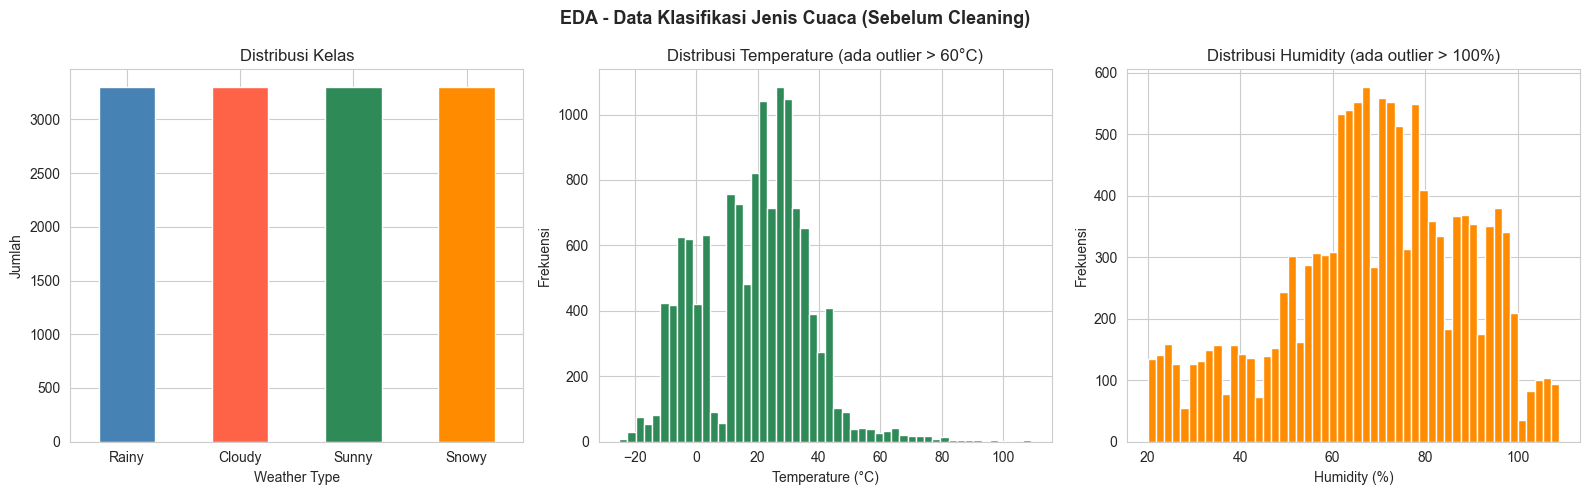

In [ ]:
# Membuat figure dengan 3 subplot berjajar horizontal, ukuran 16x5 inci
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Menambahkan judul utama untuk keseluruhan figure
fig.suptitle('EDA - Data Klasifikasi Jenis Cuaca (Sebelum Cleaning)', fontsize=13, fontweight='bold')

# --------------------------------------------------------- SUBPLOT 1: Distribusi Kelas ----------------------------------------------------------------------

# Menghitung frekuensi tiap nilai di kolom Weather Type, lalu menampilkannya
# sebagai bar chart di subplot pertama (axes[0])
# Setiap kelas cuaca diberi warna berbeda agar mudah dibedakan secara visual
df['Weather Type'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato', 'seagreen', 'darkorange'],
    edgecolor='white'
)

# Menambahkan judul dan label sumbu X dan Y pada subplot pertama
axes[0].set_title('Distribusi Kelas')
axes[0].set_xlabel('Weather Type')
axes[0].set_ylabel('Jumlah')

# Mengatur label sumbu X agar tidak dirotasi (tetap horizontal / 0 derajat)
axes[0].tick_params(rotation=0)

# ------------------------------------------------------- SUBPLOT 2: Histogram Temperature -------------------------------------------------------------------

# Menghapus nilai NaN terlebih dahulu, lalu membuat histogram Temperature
# dengan 50 bin, warna hijau, di subplot kedua (axes[1])
# Histogram ini menampilkan persebaran suhu untuk mendeteksi nilai ekstrem (outlier)
df['Temperature'].dropna().hist(ax=axes[1], bins=50, color='seagreen', edgecolor='white')

# Menambahkan judul dan label sumbu pada subplot kedua
# Judul menyebutkan adanya outlier sebagai catatan untuk EDA
axes[1].set_title('Distribusi Temperature (ada outlier > 60\u00b0C)')
axes[1].set_xlabel('Temperature (\u00b0C)')
axes[1].set_ylabel('Frekuensi')

# -------------------------------------------------------- SUBPLOT 3: Histogram Humidity ---------------------------------------------------------------------

# Menghapus nilai NaN terlebih dahulu, lalu membuat histogram Humidity
# dengan 50 bin, warna oranye, di subplot ketiga (axes[2])
# Histogram ini menampilkan persebaran kelembaban untuk mendeteksi nilai di atas 100% (tidak valid)
df['Humidity'].dropna().hist(ax=axes[2], bins=50, color='darkorange', edgecolor='white')

# Menambahkan judul dan label sumbu pada subplot ketiga
# Judul menyebutkan adanya outlier sebagai catatan untuk EDA
axes[2].set_title('Distribusi Humidity (ada outlier > 100%)')
axes[2].set_xlabel('Humidity (%)')
axes[2].set_ylabel('Frekuensi')

# Merapikan tata letak agar antar subplot tidak saling bertumpuk
plt.tight_layout()

# Menampilkan semua subplot ke layar
plt.show()

# FASE 3 - DATA PREPARATION

In [ ]:
# ============================================================================================================================================================
#                                                               FASE 3 - DATA PREPARATION
# ============================================================================================================================================================

print('=' * 60)
print(' FASE 3: DATA PREPARATION - Klasifikasi Jenis Cuaca')
print('=' * 60)

# Membuat salinan dataset asli agar data original tidak berubah selama proses cleaning
df_clean = df.copy()

# Step 1: Hapus baris yang duplikat (isi semua kolom sama persis)
# Menyimpan jumlah baris sebelum penghapusan untuk dilaporkan hasilnya
before = len(df_clean)
df_clean = df_clean.drop_duplicates()

print(f'\nStep 1 | Hapus Duplikat : {before - len(df_clean)} baris dihapus')

 FASE 3: DATA PREPARATION - Klasifikasi Jenis Cuaca

Step 1 | Hapus Duplikat : 0 baris dihapus


In [ ]:
# Step 2: Strip whitespace - menghapus spasi di awal dan akhir nilai string
# Ini mencegah masalah seperti 'Rainy ' != 'Rainy' yang bisa merusak encoding nantinya

# Mengambil daftar semua kolom bertipe object (string/kategorikal)
str_cols = df_clean.select_dtypes(include='object').columns

for col in str_cols:
    # Konversi ke string lalu hapus spasi di kedua ujung
    df_clean[col] = df_clean[col].astype(str).str.strip()
    # Ganti string 'nan' (hasil konversi nilai kosong) kembali menjadi NaN asli
    df_clean[col] = df_clean[col].replace({'nan': np.nan})

print(f'Step 2 | Strip Whitespace : selesai pada {len(str_cols)} kolom')

Step 2 | Strip Whitespace : selesai pada 4 kolom


In [ ]:
# Step 3: Hapus outlier Temperature
# Batas valid suhu harian: -50°C (kutub ekstrem) hingga 60°C (suhu panas ekstrem)
# Nilai di luar rentang ini dianggap tidak valid dan dihapus
before = len(df_clean)

# Kondisi: baris dipertahankan jika Temperature NaN (akan diimputasi nanti)
# atau jika nilainya berada dalam rentang -50 s.d. 60
df_clean = df_clean[
    (df_clean['Temperature'].isna()) |
    ((df_clean['Temperature'] >= -50) & (df_clean['Temperature'] <= 60))
]

print(f'Step 3 | Hapus Outlier Temperature : {before - len(df_clean)} baris dihapus')

Step 3 | Hapus Outlier Temperature : 207 baris dihapus


In [ ]:
# Step 4: Hapus outlier Humidity
# Kelembaban (Humidity) secara fisika hanya bisa bernilai antara 0% hingga 100%
# Nilai di atas 100% adalah tidak valid dan perlu dihapus
before = len(df_clean)

# Kondisi: baris dipertahankan jika Humidity NaN atau nilainya dalam rentang 0-100
df_clean = df_clean[
    (df_clean['Humidity'].isna()) |
    ((df_clean['Humidity'] >= 0) & (df_clean['Humidity'] <= 100))
]

print(f'Step 4 | Hapus Outlier Humidity    : {before - len(df_clean)} baris dihapus')

Step 4 | Hapus Outlier Humidity    : 369 baris dihapus


In [ ]:
# Step 5: Hapus outlier UV Index
# Skala UV Index standar WHO berkisar antara 0 (tidak ada) hingga 11+ (ekstrem)
# Nilai di atas 11 dianggap tidak valid untuk dataset cuaca harian
before = len(df_clean)

# Kondisi: baris dipertahankan jika UV Index NaN atau nilainya dalam rentang 0-11
df_clean = df_clean[
    (df_clean['UV Index'].isna()) |
    ((df_clean['UV Index'] >= 0) & (df_clean['UV Index'] <= 11))
]

print(f'Step 5 | Hapus Outlier UV Index    : {before - len(df_clean)} baris dihapus')

Step 5 | Hapus Outlier UV Index    : 499 baris dihapus


In [ ]:
# Step 6: Imputasi missing values (mengisi nilai yang kosong)
# Tujuan: agar tidak ada NaN yang bisa menyebabkan error saat training model

# Untuk kolom numerik: isi dengan nilai MEDIAN (lebih robust terhadap outlier dibanding mean)
for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Untuk kolom kategorikal: isi dengan MODUS (nilai yang paling sering muncul)
for col in df_clean.select_dtypes(include='object').columns:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

print(f'Step 6 | Imputasi Missing : selesai')

# Menampilkan ukuran data setelah seluruh proses cleaning selesai
print(f'\nShape AKHIR : {df_clean.shape}')

# Verifikasi tidak ada missing values yang tersisa
print(f'Missing sisa: {df_clean.isnull().sum().sum()}')

Step 6 | Imputasi Missing : selesai

Shape AKHIR : (12125, 11)
Missing sisa: 0


In [ ]:
# Step 7: Label Encoding - mengubah kolom kategorikal menjadi angka
# Algoritma Machine Learning tidak bisa membaca teks, sehingga perlu dikonversi ke angka
from sklearn.preprocessing import LabelEncoder

# Membuat salinan data bersih untuk proses modeling agar df_clean tetap tersimpan
df_model = df_clean.copy()

# Dictionary untuk menyimpan setiap encoder agar bisa digunakan kembali saat decoding
le_dict  = {}

# Kolom yang perlu di-encode: 3 fitur kategorikal + 1 kolom target
cat_cols = ['Cloud Cover', 'Season', 'Location', 'Weather Type']

for col in cat_cols:
    le = LabelEncoder()
    # fit_transform: belajar mapping lalu langsung mengubah nilai kolom menjadi angka
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le

# Menampilkan mapping label target (Weather Type) sebagai referensi
# agar kita tahu angka 0,1,2,3 merepresentasikan kelas cuaca apa
print('Mapping Label Weather Type:')
for i, cls in enumerate(le_dict['Weather Type'].classes_):
    print(f'  {i} = {cls}')

# Menampilkan 5 baris pertama data setelah encoding sebagai verifikasi
print(f'\nContoh data setelah encoding:')
df_model.head()

Mapping Label Weather Type:
  0 = Cloudy
  1 = Rainy
  2 = Snowy
  3 = Sunny

Contoh data setelah encoding:


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


# FASE 4 - MODELLING: Random Forest

In [ ]:
# ============================================================================================================================================================
#                                                          FASE 4 - MODELLING: Random Forest
# ============================================================================================================================================================

# Import algoritma Random Forest dan tools pendukung modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report,   # Laporan lengkap per kelas
    confusion_matrix,        # Matriks prediksi vs aktual
    accuracy_score,          # Persentase prediksi benar
    precision_score,         # Ketepatan prediksi positif
    recall_score,            # Kemampuan mendeteksi kelas yang benar
    f1_score                 # Rata-rata harmonis precision dan recall
)

print('=' * 60)
print(' FASE 4: MODELING - Random Forest')
print('=' * 60)

print('''
Random Forest bekerja dengan cara:
  1. Membuat banyak Decision Tree dari sampel acak data (Bootstrap)
  2. Setiap pohon hanya menggunakan subset fitur secara acak
  3. Prediksi akhir = voting mayoritas dari semua pohon (Ensemble)

Keunggulan:
  - Tahan terhadap overfitting dibanding Decision Tree tunggal
  - Mampu menangani data berskala besar
  - Menghasilkan feature importance secara otomatis
''')

# Mendefinisikan daftar fitur (variabel independen) yang akan digunakan sebagai input model
# Semua kolom kecuali kolom target 'Weather Type'
features = [
    'Temperature',         # Suhu udara (°C)
    'Humidity',            # Kelembaban udara (%)
    'Wind Speed',          # Kecepatan angin (km/h)
    'Precipitation (%)',   # Curah hujan (%)
    'Cloud Cover',         # Tutupan awan (encoded)
    'Atmospheric Pressure',# Tekanan atmosfer (hPa)
    'UV Index',            # Indeks UV
    'Season',              # Musim (encoded)
    'Visibility (km)',     # Jarak pandang (km)
    'Location'             # Lokasi geografis (encoded)
]

# Kolom target: jenis cuaca yang ingin diprediksi
target = 'Weather Type'

# Memisahkan fitur (X) dan target (y) dari DataFrame
X = df_model[features].values
y = df_model[target].values

# Membagi data menjadi training set (80%) dan testing set (20%)
# stratify=y memastikan proporsi setiap kelas cuaca tetap seimbang di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set : {X_train.shape[0]} sampel')
print(f'Testing set  : {X_test.shape[0]} sampel')

# ---- Hyperparameter Tuning dengan GridSearchCV ----
# GridSearchCV mencoba semua kombinasi parameter dan memilih yang terbaik
# menggunakan 5-fold Cross Validation pada data training
print('\nHyperparameter Tuning dengan GridSearchCV (5-fold CV)...')

param_grid = {
    'n_estimators': [50, 100, 200],    # Jumlah pohon keputusan dalam forest
    'max_depth'   : [None, 10, 20, 30] # Kedalaman maksimum setiap pohon (None = tidak dibatasi)
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42), # Model dasar yang akan di-tuning
    param_grid = param_grid,  # Kombinasi parameter yang akan dicoba
    cv         = 5,           # 5-fold cross validation
    scoring    = 'accuracy',  # Metrik yang dioptimalkan
    n_jobs     = -1,          # Gunakan semua core CPU agar lebih cepat
    verbose    = 1            # Tampilkan progress training
)

# Melatih model dengan semua kombinasi parameter pada data training
grid_search.fit(X_train, y_train)

# Mengambil model terbaik hasil GridSearchCV
rf_model = grid_search.best_estimator_

print(f'\nModel Random Forest berhasil dilatih!')
print(f'Best Parameters  : {grid_search.best_params_}')
print(f'Best CV Accuracy : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)')
print(f'Jumlah pohon     : {rf_model.n_estimators}')
print(f'Kedalaman pohon  : {rf_model.max_depth}')

 FASE 4: MODELING - Random Forest

Random Forest bekerja dengan cara:
  1. Membuat banyak Decision Tree dari sampel acak data (Bootstrap)
  2. Setiap pohon hanya menggunakan subset fitur secara acak
  3. Prediksi akhir = voting mayoritas dari semua pohon (Ensemble)

Keunggulan:
  - Tahan terhadap overfitting dibanding Decision Tree tunggal
  - Mampu menangani data berskala besar
  - Menghasilkan feature importance secara otomatis

Training set : 9700 sampel
Testing set  : 2425 sampel

Hyperparameter Tuning dengan GridSearchCV (5-fold CV)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Model Random Forest berhasil dilatih!
Best Parameters  : {'max_depth': 10, 'n_estimators': 200}
Best CV Accuracy : 0.9335 (93.35%)
Jumlah pohon     : 200
Kedalaman pohon  : 10


# FASE 5 - EVALUATION

In [ ]:
# ========================================================================================================================
#                                            FASE 5 - EVALUATION
# ========================================================================================================================

print('=' * 60)
print(' FASE 5: EVALUATION - Random Forest')
print('=' * 60)

# Menggunakan model terbaik untuk memprediksi kelas cuaca pada data testing
y_pred = rf_model.predict(X_test)

# Mengambil nama kelas asli (Cloudy, Rainy, Snowy, Sunny) dari LabelEncoder
labels = le_dict['Weather Type'].classes_

# Menghitung metrik evaluasi model
acc  = accuracy_score(y_test, y_pred)                          # Proporsi prediksi yang benar
prec = precision_score(y_test, y_pred, average='weighted')     # Ketepatan prediksi per kelas
rec  = recall_score(y_test, y_pred, average='weighted')        # Kemampuan mendeteksi tiap kelas
f1   = f1_score(y_test, y_pred, average='weighted')            # Keseimbangan precision dan recall

print(f'\nAccuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-Score  : {f1:.4f}')

# Menampilkan laporan klasifikasi lengkap per kelas cuaca
# Berisi precision, recall, f1-score, dan support untuk setiap kelas
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=labels))

# Cross Validation: mengevaluasi model dengan membagi data menjadi 5 bagian secara bergantian
# Tujuan: memastikan performa model konsisten, tidak hanya bagus di satu pembagian data
cv_scores = cross_val_score(
    rf_model, X, y,
    cv=5,
    scoring='accuracy'
)

print(f'\nCross Validation (5-fold):')
print(f'Scores : {cv_scores.round(4)}')   # Akurasi tiap fold
print(f'Mean   : {cv_scores.mean():.4f}') # Rata-rata akurasi semua fold
print(f'Std    : {cv_scores.std():.4f}')  # Standar deviasi (makin kecil makin stabil)

# Mengecek apakah model berhasil memenuhi kriteria sukses yang sudah ditetapkan di Fase 1
print('\nKriteria Sukses:')
print(
    f'  Accuracy >= 80% : '
    f'{"TERCAPAI" if acc >= 0.80 else "BELUM"} '
    f'({acc*100:.1f}%)'
)
print(
    f'  Recall   >= 80% : '
    f'{"TERCAPAI" if rec >= 0.80 else "BELUM"} '
    f'({rec*100:.1f}%)'
)

 FASE 5: EVALUATION - Random Forest

Accuracy  : 0.9357 (93.57%)
Precision : 0.9359
Recall    : 0.9357
F1-Score  : 0.9357

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.92      0.93      0.92       605
       Rainy       0.93      0.94      0.93       612
       Snowy       0.96      0.94      0.95       613
       Sunny       0.94      0.94      0.94       595

    accuracy                           0.94      2425
   macro avg       0.94      0.94      0.94      2425
weighted avg       0.94      0.94      0.94      2425


Cross Validation (5-fold):
Scores : [0.9365 0.9377 0.9229 0.9328 0.9274]
Mean   : 0.9315
Std    : 0.0056

Kriteria Sukses:
  Accuracy >= 80% : TERCAPAI (93.6%)
  Recall   >= 80% : TERCAPAI (93.6%)


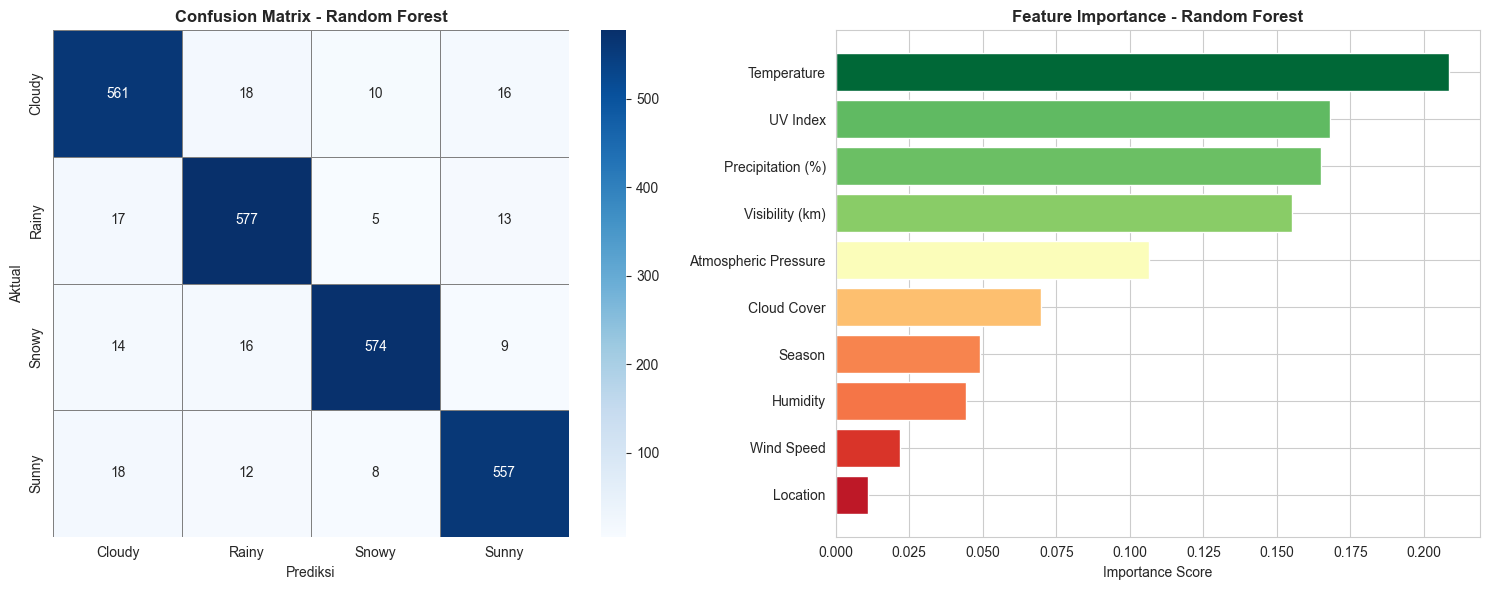

In [ ]:
# Membuat figure dengan 2 subplot berjajar: Confusion Matrix dan Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --------------------------------------------------------------- Plot 1: Confusion Matrix -------------------------------------------------------------------

# Menghitung confusion matrix: membandingkan prediksi model vs nilai aktual
# Baris = kelas aktual, Kolom = kelas prediksi
# Diagonal utama = prediksi benar, luar diagonal = prediksi salah
cm = confusion_matrix(y_test, y_pred)

# Menampilkan confusion matrix sebagai heatmap berwarna
# fmt='d' menampilkan angka bulat, cmap='Blues' menggunakan gradasi warna biru
sns.heatmap(
    cm,
    annot=True,           # Tampilkan angka di setiap sel
    fmt='d',              # Format angka bulat (integer)
    cmap='Blues',         # Warna gradasi biru: semakin gelap = semakin banyak
    xticklabels=labels,   # Label sumbu X (kelas prediksi)
    yticklabels=labels,   # Label sumbu Y (kelas aktual)
    ax=axes[0],
    linewidths=0.5,
    linecolor='gray'
)

axes[0].set_title('Confusion Matrix - Random Forest', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# ------------------------------------------------------------- Plot 2: Feature Importance -------------------------------------------------------------------

# Mengambil nilai feature importance dari model Random Forest
# Feature importance menunjukkan seberapa besar kontribusi setiap fitur dalam pengambilan keputusan
importance_df = pd.DataFrame({
    'Fitur'      : features,
    'Importance' : rf_model.feature_importances_
}).sort_values('Importance', ascending=True)  # Urutkan dari terkecil agar bar terpanjang ada di atas

# Memberi warna gradasi dari merah (penting rendah) ke hijau (penting tinggi)
colors = plt.cm.RdYlGn(
    importance_df['Importance'] / importance_df['Importance'].max()
)

# Membuat horizontal bar chart feature importance
axes[1].barh(
    importance_df['Fitur'],
    importance_df['Importance'],
    color=colors,
    edgecolor='white'
)

axes[1].set_title('Feature Importance - Random Forest', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Importance Score')

# Merapikan layout dan menampilkan plot
plt.tight_layout()
plt.show()

# FASE 6 - DEPLOYMENT

 RINGKASAN PERBANDINGAN MODEL KLASIFIKASI
                 Studi Kasus     Algoritma Accuracy Precision Recall F1-Score
SK - Klasifikasi Jenis Cuaca Random Forest   93.57%    0.9359 0.9357   0.9357


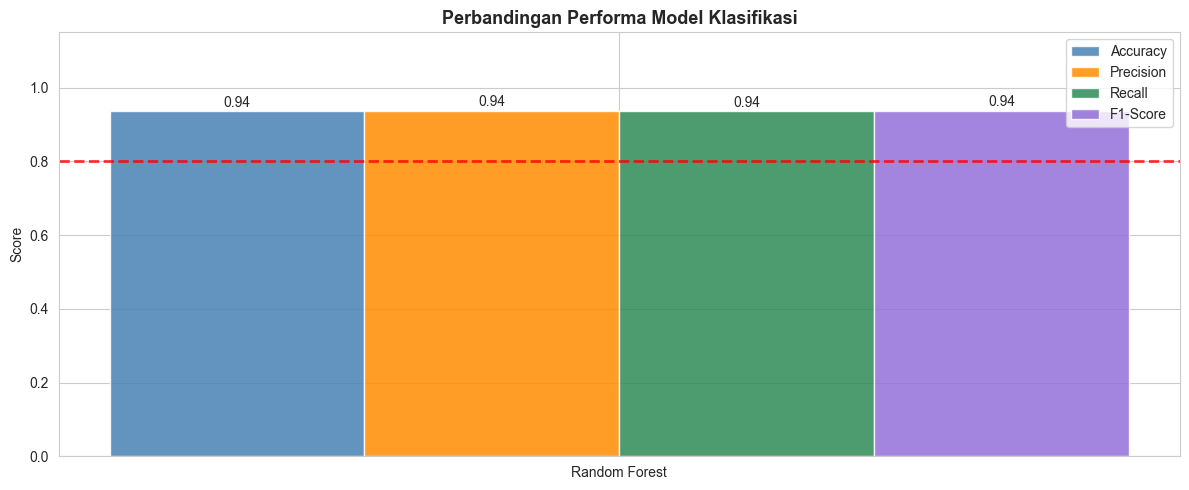


KESIMPULAN CRISP-DM:

1. Business Understanding
   -> Tujuan: mengklasifikasikan 4 jenis cuaca (Rainy, Sunny, Cloudy, Snowy)
      secara otomatis menggunakan data sensor lingkungan

2. Data Understanding
   -> Dataset: 13.200 baris, 11 kolom dari Kaggle (Weather Type Classification)
      EDA: ditemukan outlier pada Temperature (>60°C), Humidity (>100%), UV Index (>11)

3. Data Preparation
   -> 7 langkah: hapus duplikat, strip whitespace, hapus outlier Temperature,
      hapus outlier Humidity, hapus outlier UV Index, imputasi missing values,
      label encoding

4. Modelling
   -> Random Forest dengan GridSearchCV (5-fold CV)
      Ensemble learning: voting mayoritas dari banyak Decision Tree
      Dipilih karena tahan overfitting dan akurasi tinggi pada data tabular

5. Evaluation
   -> Confusion Matrix, Accuracy, Precision, Recall, F1-Score, Cross Validation
      Kriteria sukses Accuracy >= 80% dan Recall >= 80% : TERCAPAI

6. Deployment
   -> Model dipublikasikan melalui Googl

In [ ]:
# ============================================================================================================================================================
#                                                                 RINGKASAN AKHIR
# ============================================================================================================================================================

print('=' * 70)
print(' RINGKASAN PERBANDINGAN MODEL KLASIFIKASI')
print('=' * 70)

# Membuat tabel ringkasan performa model dalam bentuk DataFrame
summary = pd.DataFrame({
    'Studi Kasus' : ['SK - Klasifikasi Jenis Cuaca'],
    'Algoritma'   : ['Random Forest'],
    'Accuracy'    : [f'{acc*100:.2f}%'],
    'Precision'   : [f'{prec:.4f}'],
    'Recall'      : [f'{rec:.4f}'],
    'F1-Score'    : [f'{f1:.4f}']
})

# Menampilkan tabel ringkasan tanpa index
print(summary.to_string(index=False))


# ============================================================================================================================================================
#                                                               VISUALISASI PERBANDINGAN
# ============================================================================================================================================================

fig, ax = plt.subplots(figsize=(12, 5))

# Daftar nama model dan nilai setiap metrik untuk divisualisasikan
models  = ['Random Forest']
metrics = {
    'Accuracy' : [acc],
    'Precision': [prec],
    'Recall'   : [rec],
    'F1-Score' : [f1]
}

# Mengatur posisi bar di sumbu X agar tidak saling tumpang tindih
x          = np.arange(len(models))
width      = 0.2             # Lebar setiap bar
colors_bar = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

# Membuat bar untuk setiap metrik secara berdampingan
for i, (metric, values) in enumerate(metrics.items()):
    bars = ax.bar(
        x + i * width,
        values,
        width,
        label=metric,
        color=colors_bar[i],
        alpha=0.85,
        edgecolor='white'
    )

    # Menambahkan label nilai di atas setiap bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

# Mengatur tampilan sumbu dan judul grafik
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.15)  # Batas atas 1.15 agar label nilai tidak terpotong
ax.set_title('Perbandingan Performa Model Klasifikasi', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.legend()

# Menambahkan garis merah putus-putus sebagai penanda batas minimum kriteria sukses (80%)
ax.axhline(
    y=0.8,
    color='red',
    linestyle='--',
    linewidth=2,
    alpha=0.8,
    label='Target 80%'
)

plt.tight_layout()
plt.show()


# ============================================================================================================================================================
#                                                                KESIMPULAN CRISP-DM
# ============================================================================================================================================================

print('''
KESIMPULAN CRISP-DM:

1. Business Understanding
   -> Tujuan: mengklasifikasikan 4 jenis cuaca (Rainy, Sunny, Cloudy, Snowy)
      secara otomatis menggunakan data sensor lingkungan

2. Data Understanding
   -> Dataset: 13.200 baris, 11 kolom dari Kaggle (Weather Type Classification)
      EDA: ditemukan outlier pada Temperature (>60\u00b0C), Humidity (>100%), UV Index (>11)

3. Data Preparation
   -> 7 langkah: hapus duplikat, strip whitespace, hapus outlier Temperature,
      hapus outlier Humidity, hapus outlier UV Index, imputasi missing values,
      label encoding

4. Modelling
   -> Random Forest dengan GridSearchCV (5-fold CV)
      Ensemble learning: voting mayoritas dari banyak Decision Tree
      Dipilih karena tahan overfitting dan akurasi tinggi pada data tabular

5. Evaluation
   -> Confusion Matrix, Accuracy, Precision, Recall, F1-Score, Cross Validation
      Kriteria sukses Accuracy >= 80% dan Recall >= 80% : TERCAPAI

6. Deployment
   -> Model Random Forest siap diintegrasikan ke sistem prediksi cuaca otomatis
   -> Rekomendasi: validasi berkala dengan data cuaca terbaru
''')